In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io.fits import Header
from reproject import reproject_exact
from astropy.nddata import NDData



## Test reproject exact functionality

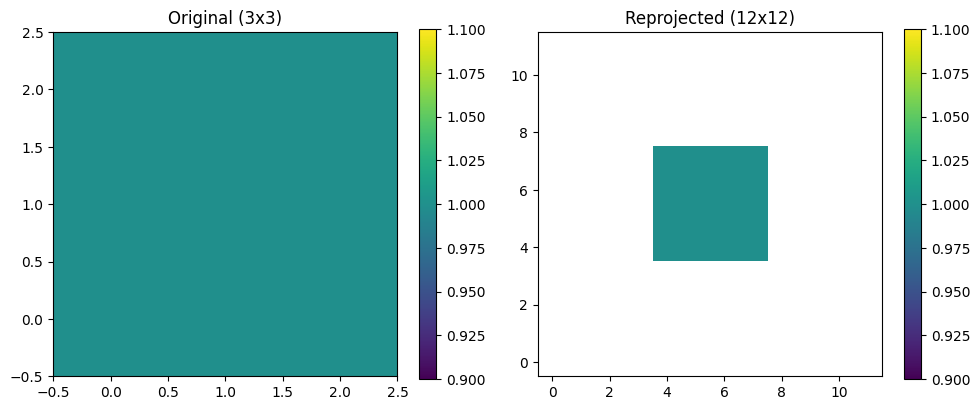

In [2]:
def create_simple_wcs(naxis1, naxis2, crval1=0, crval2=0, cdelt=1.0):
    """
    Create a simple WCS with square pixels.
    """
    header = Header()
    header['NAXIS'] = 2
    header['NAXIS1'] = naxis1
    header['NAXIS2'] = naxis2
    header['CTYPE1'] = 'RA---TAN'
    header['CTYPE2'] = 'DEC--TAN'
    header['CRPIX1'] = naxis1 / 2
    header['CRPIX2'] = naxis2 / 2
    header['CRVAL1'] = crval1
    header['CRVAL2'] = crval2
    header['CDELT1'] = -cdelt
    header['CDELT2'] = cdelt
    header['CUNIT1'] = 'deg'
    header['CUNIT2'] = 'deg'
    return WCS(header)

def test_reproject_exact():
    # Step 1: Create original data and WCS
    data = np.ones((3, 3))
    input_wcs = create_simple_wcs(3, 3)

    # Step 2: Create target header and WCS for 6x6 image
    output_wcs = create_simple_wcs(12, 12)
    output_shape = (12,12)

    # Step 3: Reproject
    reprojected_data, _ = reproject_exact((data, input_wcs), output_wcs, shape_out=output_shape)

    # Step 4: Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im1 = axes[0].imshow(data, origin='lower', cmap='viridis')
    axes[0].set_title('Original (3x3)')
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].imshow(reprojected_data, origin='lower', cmap='viridis')
    axes[1].set_title('Reprojected (12x12)')
    plt.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    plt.show()

# Run the test
test_reproject_exact()


## Align test

In [51]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS


def create_gaussian_hdus(shape=(100, 100), amplitude=1.0, sigma=5.0, separation=10):
    """
    Create three FITS HDUs containing 2D Gaussians with the same amplitude
    and sigma but separated by a few pixels, each with a dummy WCS.

    Parameters
    ----------
    shape : tuple
        Shape of the image (ny, nx)
    amplitude : float
        Peak amplitude of the Gaussian
    sigma : float
        Standard deviation of the Gaussian
    separation : int
        Pixel separation between Gaussian centers

    Returns
    -------
    hdus : list of fits.ImageHDU
        List of three HDUs
    """

    ny, nx = shape
    y, x = np.mgrid[0:ny, 0:nx]

    # Base center
    cy, cx = ny // 2, nx // 2

    centers = [
        (cy, cx),
        (cy, cx + separation),
        (cy + separation, cx)
    ]
    print(centers)

    # ----- Dummy WCS -----
    w = WCS(naxis=2)
    w.wcs.crpix = [nx / 2, ny / 2]          # reference pixel
    w.wcs.cdelt = [-0.0002, 0.0002] # ~1 arcsec/pixel
    w.wcs.crval = [150.0, 2.0]              # arbitrary RA/Dec
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    wcs_header = w.to_header()
    # ---------------------

    hdus = []

    for i, (yc, xc) in enumerate(centers):
        gauss = amplitude * np.exp(
            -((x - xc)**2 + (y - yc)**2) / (2 * sigma**2)
        )

        header = wcs_header.copy()
        hdu = fits.ImageHDU(data=gauss, header=header, name=f"GAUSS{i+1}")
        hdus.append(hdu)

    return hdus

def plot_hdus(hdus):
    """
    Plot a list of HDUs in subplots.
    """

    n = len(hdus)

    plt.figure(figsize=(4 * n, 4))

    for i, hdu in enumerate(hdus):
        plt.subplot(1, n, i + 1)
        plt.imshow(hdu.data, origin="lower", cmap="viridis")
        plt.title(hdu.name)
        plt.colorbar()

    plt.tight_layout()
    plt.show()

[(50, 50), (50, 55.4), (55.4, 50)]


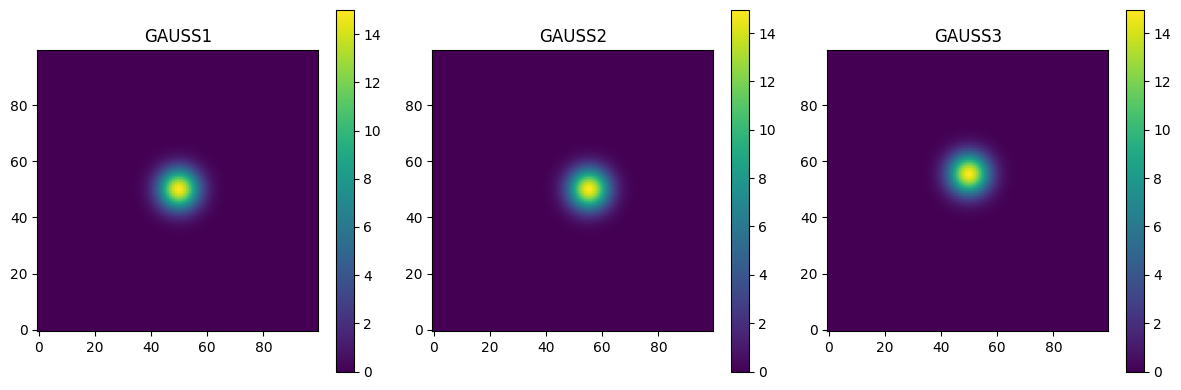

In [52]:
hdus = create_gaussian_hdus(amplitude=15, sigma=5, separation=5.4)
plot_hdus(hdus)

In [55]:
## The following is the core function that is used in ISMgas 

from reproject.mosaicking import find_optimal_celestial_wcs
from scipy.ndimage import shift
from scipy import ndimage

def reproject_and_mosaic(
    hdus,
    method='exact',
    autocorrelate=False,
    autocorrelate_maskfile=None,
    correlate_mode='full',
    resolution=None
):

    if len(hdus) == 0:
        raise ValueError("No HDUs provided.")
    if method not in ['exact', 'interp']:
        raise ValueError("method must be 'exact' or 'interp'.")

    if autocorrelate_maskfile is not None:
        userMask = fits.getdata(autocorrelate_maskfile).astype(float)
        userMask[userMask == 0] = np.nan
    else:
        userMask = None

    reproj_func = reproject_exact if method == 'exact' else reproject_interp

    if resolution is None:
        mosaic_wcs, mosaic_shape = find_optimal_celestial_wcs(hdus)
    else:
        mosaic_wcs, mosaic_shape = find_optimal_celestial_wcs(hdus, resolution=resolution)
        
    print("Optimal WCS determined. Starting reprojection and mosaic...")

    # Reference frame
    ref_hdu = hdus[0]
    ref_data, _ = reproj_func(ref_hdu, mosaic_wcs, shape_out=mosaic_shape)
    ref_data = np.nan_to_num(ref_data)

    print("Reference frame reprojected. Starting autocorrelation and alignment...")

    shifted_frames = [ref_data]
    shifts = [(0.0, 0.0)]

    # The following code uses similar approach as KCWIKit to find the optimal shifts
    # KCWI-style parameters
    search_size = 25
    conv_filter = 2
    upfactor = 10

    for hdu in hdus[1:]:
        tgt_data, _ = reproj_func(hdu, mosaic_wcs, shape_out=mosaic_shape)
        tgt_data = np.nan_to_num(tgt_data)

        if not autocorrelate:
            shifted_frames.append(tgt_data)
            shifts.append((0.0, 0.0))
            continue

        # ---------- COARSE SEARCH ----------
        crls_size = search_size + conv_filter
        xx = np.arange(-crls_size, crls_size + 1)
        yy = np.arange(-crls_size, crls_size + 1)
        crls = np.zeros((len(xx), len(yy)))

        for i, dx in enumerate(xx):
            for j, dy in enumerate(yy):
                shifted = shift(tgt_data, (dx, dy), order=1, mode='constant', cval=0.0)
                if userMask is not None:
                    valid = (userMask == userMask) # Convert to boolean
                    mult = ref_data[valid] * shifted[valid]
                else:
                    mult = ref_data * shifted
                if np.any(mult):
                    crls[i, j] = np.sum(mult)

        # Apply a maximum filter to find local maxima in the correlation map
        # The filter size is (2*conv_filter+1) to match the convolution kernel size
        max_conv = ndimage.maximum_filter(crls, 2 * conv_filter + 1)
        
        # Create a boolean mask identifying pixels that are local maxima and have non-zero correlation
        maxima = (crls == max_conv) & (crls != 0)
        labeled, _ = ndimage.label(maxima)
        slices = ndimage.find_objects(labeled)

        dxs, dys = [], []
        for slc in slices:
            cx = (slc[0].start + slc[0].stop - 1) // 2
            cy = (slc[1].start + slc[1].stop - 1) // 2
            dxs.append(cx)
            dys.append(cy)

        dxs = np.array(dxs)
        dys = np.array(dys)
        r = xx[dxs] ** 2 + yy[dys] ** 2
        idx = np.argmin(r)

        shift_y = xx[dxs[idx]]
        shift_x = yy[dys[idx]]
        
        print(f"Coarse shift found: (y: {shift_y}, x: {shift_x})")
        print("Starting fine search...")

        # ---------- FINE SEARCH ----------
        ref_up = ndimage.zoom(ref_data, upfactor, order=1, grid_mode=True, mode='grid-constant')
        tgt_up = ndimage.zoom(tgt_data, upfactor, order=1, grid_mode=True, mode='grid-constant')

        ncrl = upfactor
        fx = np.arange(-ncrl, ncrl + 1)
        fy = np.arange(-ncrl, ncrl + 1)
        crls_fine = np.zeros((len(fx), len(fy)))

        for i, dx in enumerate(fx):
            for j, dy in enumerate(fy):
                shifted = shift(
                    tgt_up,
                    (shift_y * upfactor + dx, shift_x * upfactor + dy),
                    order=1,
                    mode='constant',
                    cval=0.0
                )
                mult = ref_up * shifted
                if np.any(mult):
                    crls_fine[i, j] = np.sum(mult)

        mi, mj = np.unravel_index(np.argmax(crls_fine), crls_fine.shape)
        shift_y += fx[mi] / upfactor
        shift_x += fy[mj] / upfactor
        
        print(f"Fine shift found: (y: {shift_y}, x: {shift_x})")

        shifted_data = shift(
            tgt_data,
            (shift_y, shift_x),
            order=1,
            mode='constant',
            cval=np.nan
        )
        # print(shift_x,shift_y, resolution, resolution.value)

        shifted_frames.append(shifted_data)
        shifts.append((shift_y, shift_x))

    return shifted_frames, shifts, mosaic_wcs, mosaic_shape


In [56]:
shifted_frames, shifts, mosaic_wcs, mosaic_shape = reproject_and_mosaic(hdus, autocorrelate = True)
print(shifts)

Optimal WCS determined. Starting reprojection and mosaic...
Reference frame reprojected. Starting autocorrelation and alignment...
Coarse shift found: (y: 0, x: -5)
Starting fine search...
Fine shift found: (y: 0.0, x: -5.4)
Coarse shift found: (y: -5, x: 0)
Starting fine search...
Fine shift found: (y: -5.4, x: 0.0)
[(0.0, 0.0), (0.0, -5.4), (-5.4, 0.0)]


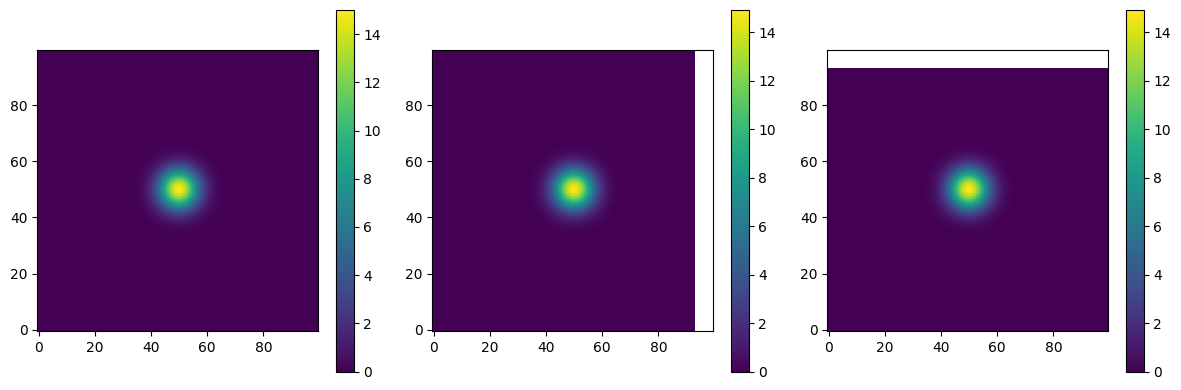

In [57]:

n=3
plt.figure(figsize=(4 * n, 4))

for i, hdu in enumerate(shifted_frames):
    plt.subplot(1, n, i + 1)
    plt.imshow(shifted_frames[i], origin="lower", cmap="viridis")
    plt.colorbar()

plt.tight_layout()
plt.show()

We are successfully able to undo the shifts and align all the frames